# Preparing Geothermal potentials for Turkey

This notebook downloads and prepares Geothermal potentials for Turkey for Pypsa-Earth-sec model.

## Import packages

In [280]:
import os
import requests
import py7zr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import country_converter as coco
from pathlib import Path
from io import BytesIO
from urllib.request import urlopen
from zipfile import ZipFile
import rasterio
import geopandas as gpd


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 70)

## Preperation

## 1. Load Data

The following tiff data were extracted from a .mpk file in ArcGIS. The .mpk file was downloaded from the webpage   https://data.4tu.nl/articles/dataset/Geoelec_data_supplement/12707681/1

The Geoelec project is described in the follwing paper: http://www.earthdoc.org/publication/publicationdetails/?publication=76526

and in this website: http://www.geoelec.eu/test-geoelec-online-viewer/

Dataset including input data and results of the European resource assessment for enhanced geothermal systems. For the assessment of geothermal resources in Europe we constructed a digital 3D temperature model of the European crust and sedimentary basins, incorporating publicly available temperature data. Using European crustal thickness models and indirect parameters such as surface heat flow measurements, temperatures were calculated for regions where data are scarce. Our temperature model of Europe has a horizontal grid resolution of 10x10 km and extends to a depth of 10 km below ground level. The model covers Europe up to the Russian border and includes Turkey and Iceland.

In [341]:
# Geothermal potenital at the Great Rift Valley, Kenya
geothermal_potential = 10000 # MW Kenya is endowed with huge geothermal potential with estimates in excess of 10,000MW due to its location along the Great Rift Valley of Eastern Africa
                              # Source: doi: 10.1016/j.proeps.2013.03.220. page 2

# PyPSA-Earth bus region distribution of Kenya
state_gdf = gpd.read_file('/mnt/e/Github-Alex/pypsa-earth/resources/base-geothmeral-behavior/bus_regions/regions_onshore_elec_s_32.geojson')

# Coordinates of the Great Rift Valley, Kenya
# Area extracted from doi: 10.1016/j.proeps.2013.03.220, figure 1 (Geothermal-Area-Great-Rift-Valley-Kenya) via https://automeris.io/wpd/.
coo_barrier = [(37.60000, -2.40452)]
coo_namarunu = [(37.43000, -2.09974)]
coo_emuruangogolak = [(37.36667, -1.55671)]
coo_silali = [(37.26333, -1.23351)]
coo_baka = [(37.22333, -1.01474)]
coo_korosi = [(37.15333, -0.84022)]
coo_lakebaringo = [(37.09667, -0.64360)]
coo_arus = [(37.10000, -0.20934)]
coo_menengai = [(37.10000, 0.12399)]
coo_eburru = [(37.23000, 0.60816)]
coo_olkaria = [(37.26333, 0.85860)]
coo_longonot = [(37.42000, 0.89575)]
coo_suswa = [(37.35667, 1.14491)]
coo_lakemagadi = [(37.22000, 1.84925)]

coordinates = [
    coo_barrier[0],
    coo_namarunu[0],
    coo_emuruangogolak[0],
    coo_silali[0],
    coo_baka[0],
    coo_korosi[0],
    coo_lakebaringo[0],
    coo_arus[0],
    coo_menengai[0],
    coo_eburru[0],
    coo_olkaria[0],
    coo_longonot[0],
    coo_suswa[0],
    coo_lakemagadi[0]
]

# Set distance to make a polygon based on the given coordinate
buffer_distance = 0.01

In [342]:
# Function to create a polygon with buffer
def create_polygon_with_buffer(coord, buffer_distance):
    return Polygon([
        (coord[0] - buffer_distance, coord[1] - buffer_distance),  # Bottom-left
        (coord[0] + buffer_distance, coord[1] - buffer_distance),  # Bottom-right
        (coord[0] + buffer_distance, coord[1] + buffer_distance),  # Top-right
        (coord[0] - buffer_distance, coord[1] + buffer_distance),  # Top-left
        (coord[0] - buffer_distance, coord[1] - buffer_distance)   # Closing the polygon
    ])

# Create polygons for all geothermal coordinates
polygons = [create_polygon_with_buffer(coord, buffer_distance) for coord in coordinates]

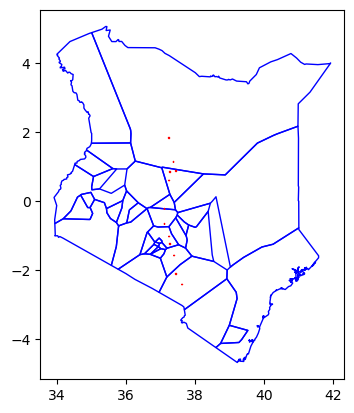

In [343]:
# Plot the geothermal coordinates in relation to pypsa-earth region
polygons_gdf = gpd.GeoDataFrame({'geometry': polygons}, crs=state_gdf.crs)
fig, ax = plt.subplots()
state_gdf.boundary.plot(ax=ax, color='blue', linewidth=1)
polygons_gdf.boundary.plot(ax=ax, color='red', linewidth=1)
plt.show()

In [352]:
# Check if each polygon in polygons is within any polygon in state_gdf
state_gdf['inside_polygon'] = state_gdf.geometry.apply(lambda x: any(poly.within(x) for poly in polygons))

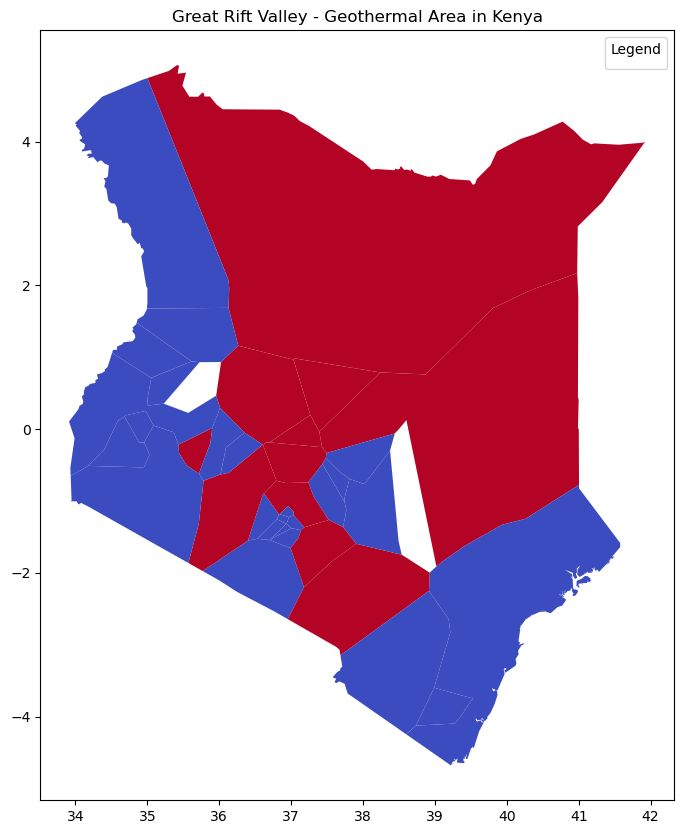

In [353]:
# Plot geothermal coordinates in relation to pypsa-earth region
gdf = state_gdf.copy()
# Create a new column 'color' based on the condition you specified
gdf['color'] = 'blue'
gdf.loc[gdf['inside_polygon'] == True, 'color'] = 'red'

# Plot the GeoDataFrame with colors
fig, ax = plt.subplots(figsize=(10, 10))

# Plot states with colors based on the 'color' column
gdf.plot(ax=ax, column='color', legend=True, cmap='coolwarm')

# Set the title
plt.title('Great Rift Valley - Geothermal Area in Kenya')

# Set the legend labels using the 'name' attribute
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Legend')

# Show the plot
plt.show()

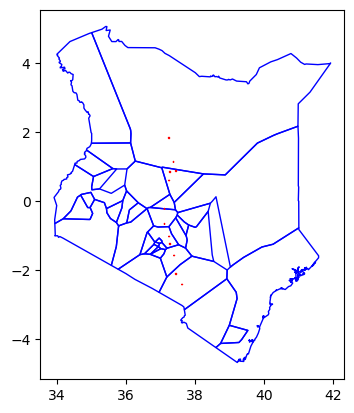

In [264]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# Load the GeoDataFrame
state_gdf = gpd.read_file('/mnt/e/Github-Alex/pypsa-earth/resources/base-geothmeral-behavior/bus_regions/regions_onshore_elec_s_32.geojson')

# Define the coordinates
coordinates = [
    (37.60000, -2.40452),
    (37.43000, -2.09974),
    (37.36667, -1.55671),
    (37.26333, -1.23351),
    (37.22333, -1.01474),
    (37.15333, -0.84022),
    (37.09667, -0.64360),
    (37.10000, -0.20934),
    (37.10000, 0.12399),
    (37.23000, 0.60816),
    (37.26333, 0.85860),
    (37.42000, 0.89575),
    (37.35667, 1.14491),
    (37.22000, 1.84925)
]

# Increase the buffer distance
buffer_distance = 0.01

# Function to create a polygon with buffer
def create_polygon_with_buffer(coord, buffer_distance):
    return Polygon([
        (coord[0] - buffer_distance, coord[1] - buffer_distance),  # Bottom-left
        (coord[0] + buffer_distance, coord[1] - buffer_distance),  # Bottom-right
        (coord[0] + buffer_distance, coord[1] + buffer_distance),  # Top-right
        (coord[0] - buffer_distance, coord[1] + buffer_distance),  # Top-left
        (coord[0] - buffer_distance, coord[1] - buffer_distance)   # Closing the polygon
    ])

# Create polygons for all coordinates
polygons = [create_polygon_with_buffer(coord, buffer_distance) for coord in coordinates]

# Create a GeoDataFrame for the polygons
#polygons_gdf = gpd.GeoDataFrame({'geometry': polygons}, crs=state_gdf.crs)

# Plot the state_gdf and polygons
fig, ax = plt.subplots()
state_gdf.boundary.plot(ax=ax, color='blue', linewidth=1)
polygons_gdf.boundary.plot(ax=ax, color='red', linewidth=1)
plt.show()


In [279]:
import geopandas as gpd
from shapely.geometry import Polygon

# Load the GeoDataFrame
state_gdf = gpd.read_file('/mnt/e/Github-Alex/pypsa-earth/resources/base-geothmeral-behavior/bus_regions/regions_onshore_elec_s_32.geojson')

# Define the coordinates
coordinates = [
    (37.60000, -2.40452),
    (37.43000, -2.09974),
    (37.36667, -1.55671),
    (37.26333, -1.23351),
    (37.22333, -1.01474),
    (37.15333, -0.84022),
    (37.09667, -0.64360),
    (37.10000, -0.20934),
    (37.10000, 0.12399),
    (37.23000, 0.60816),
    (37.26333, 0.85860),
    (37.42000, 0.89575),
    (37.35667, 1.14491),
    (37.22000, 1.84925)
]

# Increase the buffer distance
buffer_distance = 0.01

# Function to create a polygon with buffer
def create_polygon_with_buffer(coord, buffer_distance):
    return Polygon([
        (coord[0] - buffer_distance, coord[1] - buffer_distance),  # Bottom-left
        (coord[0] + buffer_distance, coord[1] - buffer_distance),  # Bottom-right
        (coord[0] + buffer_distance, coord[1] + buffer_distance),  # Top-right
        (coord[0] - buffer_distance, coord[1] + buffer_distance),  # Top-left
        (coord[0] - buffer_distance, coord[1] - buffer_distance)   # Closing the polygon
    ])

# Create polygons for all coordinates
polygons = [create_polygon_with_buffer(coord, buffer_distance) for coord in coordinates]

# Check if each geometry in state_gdf intersects with any of the polygons
state_gdf['inside_polygon'] = state_gdf.geometry.apply(lambda x: any(x.intersects(p) for p in polygons))

# Print the updated DataFrame
print(state_gdf[['name', 'inside_polygon']])


   name  inside_polygon
0     1           False
1    12           False
2    13            True
3    16            True
4     2           False
5    22           False
6    24           False
7    29            True
8    31           False
9    32            True
10   34           False
11   35           False
12   37            True
13    4           False
14   40           False
15   43           False
16   44           False
17   47           False
18   48           False
19    5           False
20   51           False
21   52            True
22   55            True
23   57           False
24   58           False
25   59            True
26   65           False
27   67           False
28   69           False
29   85           False
30   86           False
31    9           False


In [269]:
# Check the CRS of state_gdf
print(state_gdf.crs)

# Set the CRS for polygons_gdf to match state_gdf
polygons_gdf = gpd.GeoDataFrame({'geometry': polygons}, crs=state_gdf.crs)


EPSG:4326


In [270]:
# Reproject polygons_gdf to match state_gdf CRS
polygons_gdf = polygons_gdf.to_crs(state_gdf.crs)

In [271]:
polygons_gdf

,geometry
0,"POLYGON ((37.59000 -2.41452, 37.61000 -2.41452, 37.61000 -2.39452,..."
1,"POLYGON ((37.42000 -2.10974, 37.44000 -2.10974, 37.44000 -2.08974,..."
2,"POLYGON ((37.35667 -1.56671, 37.37667 -1.56671, 37.37667 -1.54671,..."
3,"POLYGON ((37.25333 -1.24351, 37.27333 -1.24351, 37.27333 -1.22351,..."
4,"POLYGON ((37.21333 -1.02474, 37.23333 -1.02474, 37.23333 -1.00474,..."
5,"POLYGON ((37.14333 -0.85022, 37.16333 -0.85022, 37.16333 -0.83022,..."
6,"POLYGON ((37.08667 -0.65360, 37.10667 -0.65360, 37.10667 -0.63360,..."
7,"POLYGON ((37.09000 -0.21934, 37.11000 -0.21934, 37.11000 -0.19934,..."
8,"POLYGON ((37.09000 0.11399, 37.11000 0.11399, 37.11000 0.13399, 37..."
9,"POLYGON ((37.22000 0.59816, 37.24000 0.59816, 37.24000 0.61816, 37..."


In [277]:
# Check if points are within the polygon
state_gdf['inside_polygon'] = state_gdf.contains(polygons_gdf)

/tmp/ipykernel_4197/2523976234.py:2: UserWarning: The indices of the two GeoSeries are different.
  state_gdf['inside_polygon'] = state_gdf.contains(polygons_gdf)


In [278]:
state_gdf

,name,x,y,country,geometry,inside_polygon
0,1,36.915000,-1.258900,KE,"POLYGON ((36.93216 -1.31786, 36.80350 -1.25353, 36.82944 -1.18702,...",False
1,12,38.122050,-2.784050,KE,"MULTIPOLYGON (((38.98918 -3.59782, 39.52690 -3.74684, 39.34738 -4....",False
2,13,38.255257,-0.300457,KE,"MULTIPOLYGON (((39.09383 -1.85024, 39.02028 -1.91081, 38.60299 0.1...",False
3,16,37.068000,-0.001600,KE,"POLYGON ((37.39221 -0.03787, 37.42889 -0.25120, 36.69705 -0.18445,...",False
4,2,35.263000,0.500800,KE,"POLYGON ((35.22755 0.35413, 35.00707 0.32883, 34.99967 0.41199, 35...",False
5,22,37.888100,-0.600200,KE,"POLYGON ((38.03508 -0.74364, 37.99841 -0.75881, 37.81133 -0.69185,...",False
6,24,35.053100,1.010300,KE,"POLYGON ((35.05460 0.71293, 34.53838 1.04110, 34.51254 1.07187, 34...",False
7,29,37.542100,0.251900,KE,"POLYGON ((37.03005 0.97311, 37.05471 0.98282, 38.24016 0.78878, 37...",False
8,31,34.829800,-0.032300,KE,"POLYGON ((35.08613 0.04987, 34.95517 -0.18535, 34.88645 -0.18752, ...",False
9,32,37.028800,-0.431400,KE,"POLYGON ((37.42889 -0.25120, 37.49461 -0.33174, 37.48040 -0.40404,...",False


In [268]:
polygons

[<POLYGON ((37.59 -2.415, 37.61 -2.415, 37.61 -2.395, 37.59 -2.395, 37.59 -2....>,
 <POLYGON ((37.42 -2.11, 37.44 -2.11, 37.44 -2.09, 37.42 -2.09, 37.42 -2.11))>,
 <POLYGON ((37.357 -1.567, 37.377 -1.567, 37.377 -1.547, 37.357 -1.547, 37.35...>,
 <POLYGON ((37.253 -1.244, 37.273 -1.244, 37.273 -1.224, 37.253 -1.224, 37.25...>,
 <POLYGON ((37.213 -1.025, 37.233 -1.025, 37.233 -1.005, 37.213 -1.005, 37.21...>,
 <POLYGON ((37.143 -0.9, 37.163 -0.9, 37.163 -0.8, 37.143 -0.8, 37.143 -0.9))>,
 <POLYGON ((37.087 -0.7, 37.107 -0.7, 37.107 -0.6, 37.087 -0.6, 37.087 -0.7))>,
 <POLYGON ((37.09 -0.2, 37.11 -0.2, 37.11 -0.2, 37.09 -0.2, 37.09 -0.2))>,
 <POLYGON ((37.09 0.1, 37.11 0.1, 37.11 0.1, 37.09 0.1, 37.09 0.1))>,
 <POLYGON ((37.22 0.6, 37.24 0.6, 37.24 0.6, 37.22 0.6, 37.22 0.6))>,
 <POLYGON ((37.253 0.8, 37.273 0.8, 37.273 0.9, 37.253 0.9, 37.253 0.8))>,
 <POLYGON ((37.41 0.9, 37.43 0.9, 37.43 0.9, 37.41 0.9, 37.41 0.9))>,
 <POLYGON ((37.347 1.135, 37.367 1.135, 37.367 1.155, 37.347 1.155, 

In [272]:
state_gdf['inside_polygon'] = state_gdf.geometry.apply(lambda x: any(x.within(p) for p in polygons))

In [273]:
state_gdf

,name,x,y,country,geometry,inside_polygon
0,1,36.915000,-1.258900,KE,"POLYGON ((36.93216 -1.31786, 36.80350 -1.25353, 36.82944 -1.18702,...",False
1,12,38.122050,-2.784050,KE,"MULTIPOLYGON (((38.98918 -3.59782, 39.52690 -3.74684, 39.34738 -4....",False
2,13,38.255257,-0.300457,KE,"MULTIPOLYGON (((39.09383 -1.85024, 39.02028 -1.91081, 38.60299 0.1...",False
3,16,37.068000,-0.001600,KE,"POLYGON ((37.39221 -0.03787, 37.42889 -0.25120, 36.69705 -0.18445,...",False
4,2,35.263000,0.500800,KE,"POLYGON ((35.22755 0.35413, 35.00707 0.32883, 34.99967 0.41199, 35...",False
5,22,37.888100,-0.600200,KE,"POLYGON ((38.03508 -0.74364, 37.99841 -0.75881, 37.81133 -0.69185,...",False
6,24,35.053100,1.010300,KE,"POLYGON ((35.05460 0.71293, 34.53838 1.04110, 34.51254 1.07187, 34...",False
7,29,37.542100,0.251900,KE,"POLYGON ((37.03005 0.97311, 37.05471 0.98282, 38.24016 0.78878, 37...",False
8,31,34.829800,-0.032300,KE,"POLYGON ((35.08613 0.04987, 34.95517 -0.18535, 34.88645 -0.18752, ...",False
9,32,37.028800,-0.431400,KE,"POLYGON ((37.42889 -0.25120, 37.49461 -0.33174, 37.48040 -0.40404,...",False


In [ ]:
state_gdf.plot()

In [ ]:
gdf = state_gdf.copy()
# Create a new column 'color' based on the condition you specified
gdf['color'] = 'blue'
gdf.loc[gdf['inside_polygon'] == True, 'color'] = 'red'

# Plot the GeoDataFrame with colors
fig, ax = plt.subplots(figsize=(10, 10))

# Plot states with colors based on the 'color' column
gdf.plot(ax=ax, column='color', legend=True, cmap='coolwarm')

# Set the title
plt.title('Economical potential based on LCOE<150€/Mwh')

# Set the legend labels using the 'name' attribute
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Legend')

# Show the plot
plt.show()

In [130]:
# Geothermal potenital at the Great Rift Valley, Kenya
geothermal_potential = 10000 # MW Kenya is endowed with huge geothermal potential with estimates in excess of 10,000MW due to its location along the Great Rift Valley of Eastern Africa
                              # Source: doi: 10.1016/j.proeps.2013.03.220. page 2

# PyPSA-Earth bus region distribution of Kenya
state_gdf = gpd.read_file('/mnt/e/Github-Alex/pypsa-earth/resources/base-geothmeral-behavior/bus_regions/regions_onshore_elec_s_32.geojson')

# Coordinates of the Great Rift Valley, Kenya
# Area extracted from doi: 10.1016/j.proeps.2013.03.220, figure 1 (Geothermal-Area-Great-Rift-Valley-Kenya) via https://automeris.io/wpd/. Own settings of points ((Geothermal-Area-Great-Rift-Valley-Kenya-Set-Coordinates)).
polygon_coordinates = [(36.98000, 2.05223),
                        (37.42000, 2.29486),
                        (37.12333, 0.72517),
                        (37.52333, 0.71728),
                        (37.46000, -1.33618),
                        (37.67333, -2.49127),
                        (37.44000, -2.53381),
                        (37.21000, -1.45789),
                        (37.21000, -0.20789),
                        (36.81333, -0.05521)]

In [215]:
coo_barrier = [(37.60000, -2.40452)]
coo_namarunu = [(37.43000, -2.09974)]
coo_emuruangogolak = [(37.36667, -1.55671)]
coo_silali = [(37.26333, -1.23351)]
coo_baka = [(37.22333, -1.01474)]
coo_korosi = [(37.15333, -0.84022)]
coo_lakebaringo = [(37.09667, -0.64360)]
coo_arus = [(37.10000, -0.20934)]
coo_menengai = [(37.10000, 0.12399)]
coo_eburru = [(37.23000, 0.60816)]
coo_olkaria = [(37.26333, 0.85860)]
coo_longonot = [(37.42000, 0.89575)]
coo_suswa = [(37.35667, 1.14491)]
coo_lakemagadi = [(37.22000, 1.84925)]

coordinates = [
    coo_barrier[0],
    coo_namarunu[0],
    coo_emuruangogolak[0],
    coo_silali[0],
    coo_baka[0],
    coo_korosi[0],
    coo_lakebaringo[0],
    coo_arus[0],
    coo_menengai[0],
    coo_eburru[0],
    coo_olkaria[0],
    coo_longonot[0],
    coo_suswa[0],
    coo_lakemagadi[0]
]

buffer_distance = 0.00001

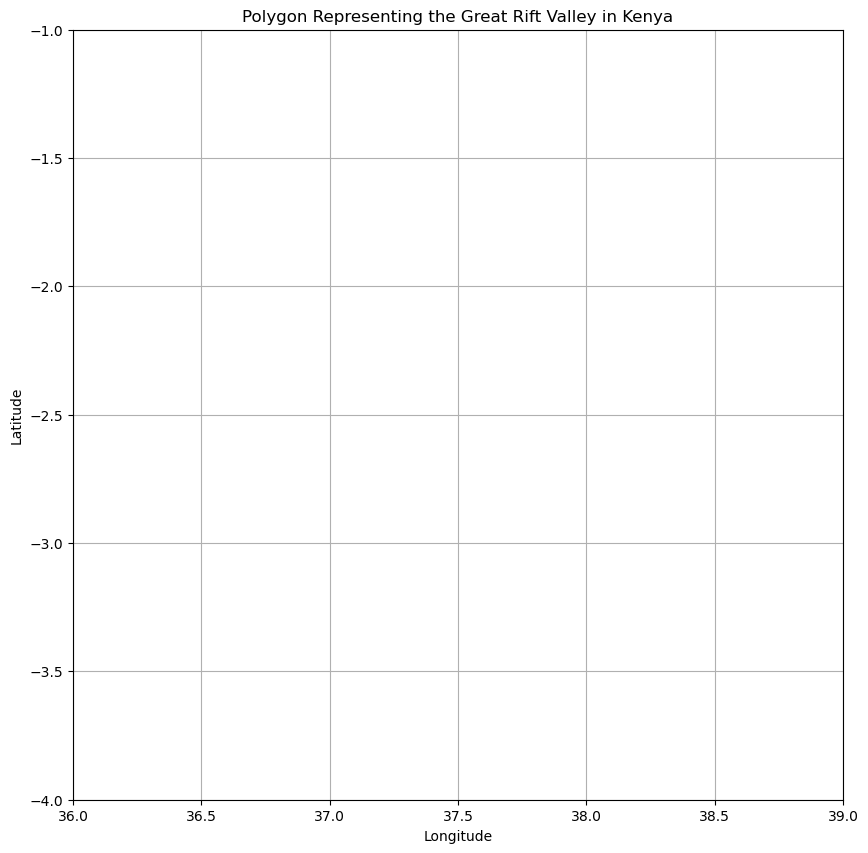

In [216]:
# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(index=[0], geometry=[polygon])

# Plotting the polygon
fig, ax = plt.subplots(figsize=(10, 10))
gdf.boundary.plot(ax=ax, color='blue', linewidth=2)
ax.set_title("Polygon Representing the Great Rift Valley in Kenya")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.xlim(36, 39)  # Adjust x-limits as needed
plt.ylim(-4, -1)   # Adjust y-limits as needed
plt.grid()
plt.show()

True


,name,x,y,country,geometry,inside_polygon,geothermal_potential[MW]
0,1,36.915000,-1.258900,KE,"POLYGON ((36.93216 -1.31786, 36.80350 -1.25353, 36.82944 -1.18702,...",False,0
1,12,38.122050,-2.784050,KE,"MULTIPOLYGON (((38.98918 -3.59782, 39.52690 -3.74684, 39.34738 -4....",False,0
2,13,38.255257,-0.300457,KE,"MULTIPOLYGON (((39.09383 -1.85024, 39.02028 -1.91081, 38.60299 0.1...",False,0
3,16,37.068000,-0.001600,KE,"POLYGON ((37.39221 -0.03787, 37.42889 -0.25120, 36.69705 -0.18445,...",False,0
4,2,35.263000,0.500800,KE,"POLYGON ((35.22755 0.35413, 35.00707 0.32883, 34.99967 0.41199, 35...",False,0
5,22,37.888100,-0.600200,KE,"POLYGON ((38.03508 -0.74364, 37.99841 -0.75881, 37.81133 -0.69185,...",False,0
6,24,35.053100,1.010300,KE,"POLYGON ((35.05460 0.71293, 34.53838 1.04110, 34.51254 1.07187, 34...",False,0
7,29,37.542100,0.251900,KE,"POLYGON ((37.03005 0.97311, 37.05471 0.98282, 38.24016 0.78878, 37...",False,0
8,31,34.829800,-0.032300,KE,"POLYGON ((35.08613 0.04987, 34.95517 -0.18535, 34.88645 -0.18752, ...",False,0
9,32,37.028800,-0.431400,KE,"POLYGON ((37.42889 -0.25120, 37.49461 -0.33174, 37.48040 -0.40404,...",False,0


In [218]:
state_gdf["inside_polygon"]

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21     True
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
Name: inside_polygon, dtype: bool

In [166]:
buffer_distance = 0.00001

coo_barrier = Polygon([
    (coo_barrier[0][0] - buffer_distance, coo_barrier[0][1] - buffer_distance),  # Bottom-left
    (coo_barrier[0][0] + buffer_distance, coo_barrier[0][1] - buffer_distance),  # Bottom-right
    (coo_barrier[0][0] + buffer_distance, coo_barrier[0][1] + buffer_distance),  # Top-right
    (coo_barrier[0][0] - buffer_distance, coo_barrier[0][1] + buffer_distance),  # Top-left
    (coo_barrier[0][0] - buffer_distance, coo_barrier[0][1] - buffer_distance)   # Closing the polygon
])

In [170]:
coo_namarunu = Polygon([
    (coo_namarunu[0][0] - buffer_distance, coo_namarunu[0][1] - buffer_distance),  # Bottom-left
    (coo_namarunu[0][0] + buffer_distance, coo_namarunu[0][1] - buffer_distance),  # Bottom-right
    (coo_namarunu[0][0] + buffer_distance, coo_namarunu[0][1] + buffer_distance),  # Top-right
    (coo_namarunu[0][0] - buffer_distance, coo_namarunu[0][1] + buffer_distance),  # Top-left
    (coo_namarunu[0][0] - buffer_distance, coo_namarunu[0][1] - buffer_distance)   # Closing the polygon
])

In [172]:
coo_lakemagadi = Polygon([
    (coo_lakemagadi[0][0] - buffer_distance, coo_lakemagadi[0][1] - buffer_distance),  # Bottom-left
    (coo_lakemagadi[0][0] + buffer_distance, coo_lakemagadi[0][1] - buffer_distance),  # Bottom-right
    (coo_lakemagadi[0][0] + buffer_distance, coo_lakemagadi[0][1] + buffer_distance),  # Top-right
    (coo_lakemagadi[0][0] - buffer_distance, coo_lakemagadi[0][1] + buffer_distance),  # Top-left
    (coo_lakemagadi[0][0] - buffer_distance, coo_lakemagadi[0][1] - buffer_distance)   # Closing the polygon
])

In [150]:
from shapely.geometry import Point

coo_barrier = Point(37.60000, -2.40452)
coo_namarunu = Point(37.43000, -2.09974)
coo_emuruangogolak = Point(37.36667, -1.55671)
coo_silali = Point(37.26333, -1.23351)
coo_baka = Point(37.22333, -1.01474)
coo_korosi = Point(37.15333, -0.84022)
coo_lakebaringo = Point(37.09667, -0.64360)
coo_arus = Point(37.10000, -0.20934)
coo_menengai = Point(37.10000, 0.12399)
coo_eburru = Point(37.23000, 0.60816)
coo_olkaria = Point(37.26333, 0.85860)
coo_longonot = Point(37.42000, 0.89575)
coo_suswa = Point(37.35667, 1.14491)
coo_lakemagadi = Point(37.22000, 1.84925)

In [147]:
state_gdf['inside_polygon'] = state_gdf.equals(coo_barrier)

In [151]:
# Check if the point is within any of the geometries
state_gdf['inside_polygon'] = state_gdf.apply(lambda geom: point.within(geom))

NameError: name 'point' is not defined

In [149]:
print(state_gdf['inside_polygon'])

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
Name: inside_polygon, dtype: bool


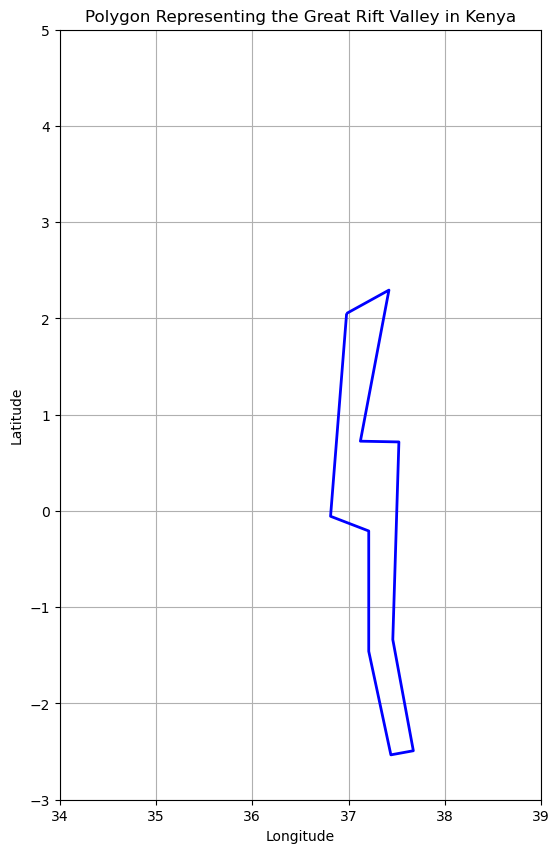

In [136]:
# Define the coordinates of the polygon
coordinates = [(36.98000, 2.05223),
                (37.42000, 2.29486),
                (37.12333, 0.72517),
                (37.52333, 0.71728),
                (37.46000, -1.33618),
                (37.67333, -2.49127),
                (37.44000, -2.53381),
                (37.21000, -1.45789),
                (37.21000, -0.20789),
                (36.81333, -0.05521)]


"""
[
    (35.0, 4.0),   # Top-left (northwest)
    (37.5, 4.0),   # Top-right (northeast)
    (37.5, -2.5),  # Bottom-right (southeast)
    (35.0, -2.5),  # Bottom-left (southwest)
    (36.0, 2.0),   # Mid-north (north-central)
    (36.0, -0.5),  # Mid-south (south-central)
    (35.5, 0.5),   # Mid-west (west-central)
    (37.0, 0.5)    # Mid-east (east-central)
]
"""

# Create a Polygon object
polygon = Polygon(coordinates)

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(index=[0], geometry=[polygon])

# Plotting the polygon
fig, ax = plt.subplots(figsize=(10, 10))
gdf.boundary.plot(ax=ax, color='blue', linewidth=2)
ax.set_title("Polygon Representing the Great Rift Valley in Kenya")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.xlim(34, 39)  # Adjust x-limits as needed
plt.ylim(-3, 5)   # Adjust y-limits as needed
plt.grid()
plt.show()

In [173]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point, Polygon

# Create a Polygon object
#polygon = Polygon(polygon_coordinates)

# Check if points are within the polygon
state_gdf['inside_polygon'] = state_gdf.intersects(coo_barrier, coo_namarunu, coo_lakemagadi)
#intersects
# Calculate the number of points inside the polygon
num_inside = state_gdf['inside_polygon'].sum()

# If there are points inside the polygon, split geothermal potential equally
state_gdf['geothermal_potential[MW]'] = 0  # Initialize the new column
state_gdf.loc[state_gdf['inside_polygon'], 'geothermal_potential[MW]'] = geothermal_potential / num_inside

state_gdf

TypeError: GeoPandasBase.intersects() takes from 2 to 3 positional arguments but 4 were given

<AxesSubplot:>

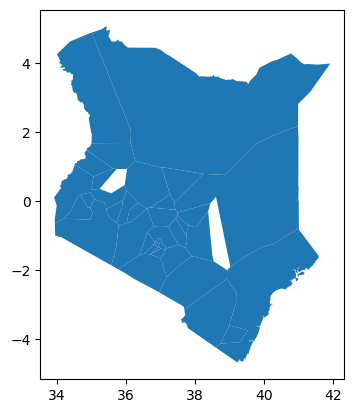

In [220]:
state_gdf.plot()

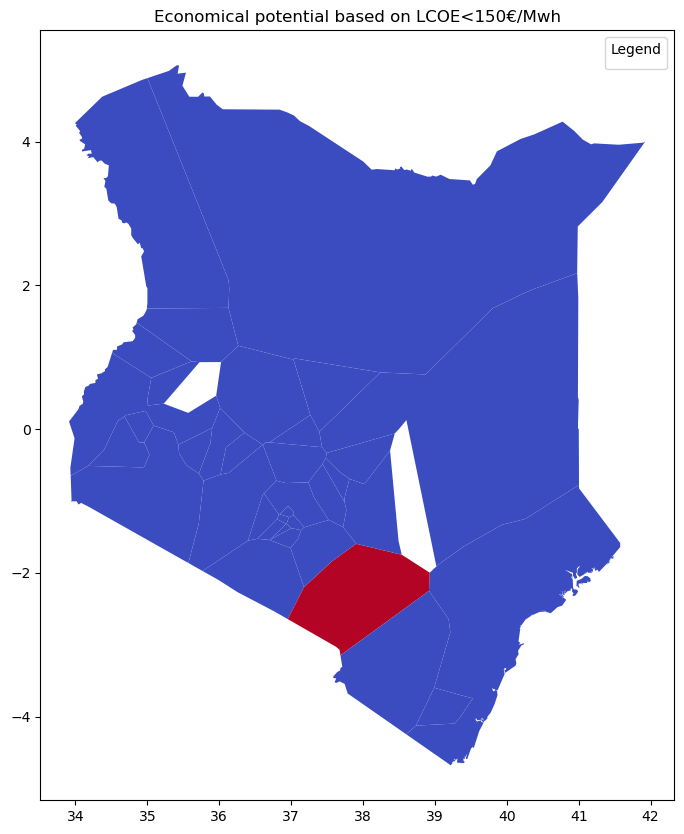

In [221]:
gdf = state_gdf.copy()
# Create a new column 'color' based on the condition you specified
gdf['color'] = 'blue'
gdf.loc[gdf['inside_polygon'] == True, 'color'] = 'red'

# Plot the GeoDataFrame with colors
fig, ax = plt.subplots(figsize=(10, 10))

# Plot states with colors based on the 'color' column
gdf.plot(ax=ax, column='color', legend=True, cmap='coolwarm')

# Set the title
plt.title('Economical potential based on LCOE<150€/Mwh')

# Set the legend labels using the 'name' attribute
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Legend')

# Show the plot
plt.show()

In [ ]:
coo_barrier = [(37.60000, -2.40452)]
coo_namarunu = [(37.43000, -2.09974)]
coo_emuruangogolak = [(37.36667, -1.55671)]
coo_silali = [(37.26333, -1.23351)]
coo_baka = [(37.22333, -1.01474)]
coo_korosi = [(37.15333, -0.84022)]
coo_lakebaringo = [(37.09667, -0.64360)]
coo_arus = [(37.10000, -0.20934)]
coo_menengai = [(37.10000, 0.12399)]
coo_eburru = [(37.23000, 0.60816)]
coo_olkaria = [(37.26333, 0.85860)]
coo_longonot = [(37.42000, 0.89575)]
coo_suswa = [(37.35667, 1.14491)]
coo_lakemagadi = [(37.22000, 1.84925)]

In [42]:
import geopandas as gpd
from shapely.geometry import Polygon

# Define the coordinates of the polygon
polygon_coordinates = [
    (35.0, 4.0),   # Top-left (northwest)
    (37.5, 4.0),   # Top-right (northeast)
    (37.5, -2.5),  # Bottom-right (southeast)
    (35.0, -2.5),  # Bottom-left (southwest)
    (36.0, 2.0),   # Mid-north (north-central)
    (36.0, -0.5),  # Mid-south (south-central)
    (35.5, 0.5),   # Mid-west (west-central)
    (37.0, 0.5)    # Mid-east (east-central)
]


# Create a Polygon object
polygon = Polygon(polygon_coordinates)

# Load your GeoJSON file
gdf_points = gpd.read_file('/mnt/e/Github-Alex/pypsa-earth/resources/base-geothmeral-behavior/bus_regions/regions_onshore_elec_s_32.geojson')

# Check if points are within the polygon
gdf_points['inside_polygon'] = gdf_points.geometry.within(polygon)

# Calculate the number of points inside the polygon
num_inside = gdf_points['inside_polygon'].sum()

# If there are points inside the polygon, split 10,000 equally
if num_inside > 0:
    gdf_points['new_column'] = 0  # Initialize the new column
    gdf_points.loc[gdf_points['inside_polygon'], 'new_column'] = 10000 / num_inside


# Display the updated GeoDataFrame
print(gdf_points)


   name          x         y country  \
0     1  36.915000 -1.258900      KE   
1    12  38.122050 -2.784050      KE   
2    13  38.255257 -0.300457      KE   
3    16  37.068000 -0.001600      KE   
4     2  35.263000  0.500800      KE   
5    22  37.888100 -0.600200      KE   
6    24  35.053100  1.010300      KE   
7    29  37.542100  0.251900      KE   
8    31  34.829800 -0.032300      KE   
9    32  37.028800 -0.431400      KE   
10   34  36.989800 -1.283500      KE   
11   35  36.717800 -1.182000      KE   
12   37  37.156140  1.449273      KE   
13    4  37.719400 -0.801200      KE   
14   40  39.782162 -3.618108      KE   
15   43  34.811150 -0.202500      KE   
16   44  35.100820 -0.577760      KE   
17   47  34.823157  0.324143      KE   
18   48  36.043450 -0.240650      KE   
19    5  35.358700  1.911700      KE   
20   51  37.591100 -0.862100      KE   
21   52  37.725400 -2.228100      KE   
22   55  37.013167 -1.101767      KE   
23   57  36.953700 -1.458800      KE   


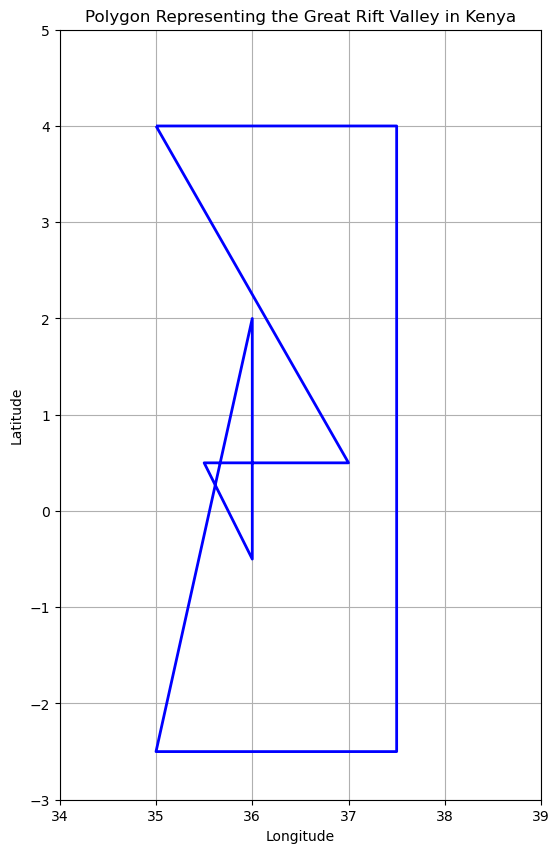

In [37]:
# Define the polygon for the Great Rift Valley, Kenya
import geopandas as gpd
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

# Define the coordinates of the polygon
coordinates = [
    (35.0, 4.0),   # Top-left (northwest)
    (37.5, 4.0),   # Top-right (northeast)
    (37.5, -2.5),  # Bottom-right (southeast)
    (35.0, -2.5),  # Bottom-left (southwest)
    (36.0, 2.0),   # Mid-north (north-central)
    (36.0, -0.5),  # Mid-south (south-central)
    (35.5, 0.5),   # Mid-west (west-central)
    (37.0, 0.5)    # Mid-east (east-central)
]

# Create a Polygon object
polygon = Polygon(coordinates)

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(index=[0], geometry=[polygon])

# Plotting the polygon
fig, ax = plt.subplots(figsize=(10, 10))
gdf.boundary.plot(ax=ax, color='blue', linewidth=2)
ax.set_title("Polygon Representing the Great Rift Valley in Kenya")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.xlim(34, 39)  # Adjust x-limits as needed
plt.ylim(-3, 5)   # Adjust y-limits as needed
plt.grid()
plt.show()

In [3]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject

# Specify the paths to your input and output TIFF files
input_tiff_path = 'Geoelec_tiff_maps/Minimum_LCOE_20301.tif'
output_tiff_path = 'Geoelec_tiff_maps/Minimum_LCOE_2030_4326.tif'

# Specify the target CRS (Coordinate Reference System)
target_crs = 'EPSG:4326'  # Change this to your desired CRS

# Open the input raster file
with rasterio.open(input_tiff_path) as src:
    # Calculate the transform for the new CRS
    transform, width, height = calculate_default_transform(src.crs, target_crs, src.width, src.height, *src.bounds)

    # Update metadata with the new CRS and transform
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': target_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    # Create the output raster file
    with rasterio.open(output_tiff_path, 'w', **kwargs) as dst:
        # Reproject the data to the new CRS
        reproject(
            source=rasterio.band(src, 1),
            destination=rasterio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=target_crs,
            resampling=rasterio.enums.Resampling.nearest  # You can choose a different resampling method
        )

In [9]:
import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
import numpy as np

# Load state GeoDataFrame
# Replace 'path/to/your/state_shapefile.shp' with the actual path to your shapefile
state_gdf = gpd.read_file('/mnt/e/Github-Alex/pypsa-earth/resources/base-geothmeral-behavior/bus_regions/regions_onshore_elec_s_32.geojson')

rasters = ['Minimum_LCOE_2030_4326',
            'Minimum_LCOE_2050_4326'
]

for f in rasters:
    # Load raster data
    # Replace 'path/to/your/file.tif' with the actual path to your TIFF file
    with rasterio.open('Geoelec_tiff_maps/{}.tif'.format(f)) as src:
        raster_data = src.read(1, masked=True)  # Use masked=True to create a masked array

    # Iterate over state geometries and calculate average pixel value
    state_averages = []

    for idx, state in state_gdf.iterrows():
        # Extract the geometry of the state
        state_geometry = state['geometry']
        
        # Use the geometry to create a mask for the raster data
        state_mask = geometry_mask([state_geometry], out_shape=raster_data.shape, transform=src.transform, invert=True)

        # Mask the raster data with the state mask
        # state_pixels = np.ma.masked_array(raster_data, state_mask)

        # Replace masked values with a fill value (e.g., 0)
        fill_value = 0
        state_pixels = np.ma.masked_array(raster_data, ~state_mask, fill_value=fill_value)

        # Calculate the average pixel value for the state excluding NoData values
        state_avg = np.ma.mean(state_pixels)
        state_averages.append(state_avg)

    # Add the averages to the state GeoDataFrame
    state_gdf[f] = state_averages

state_gdf


,name,x,y,country,geometry,Minimum_LCOE_2030_4326,Minimum_LCOE_2050_4326
0,1,36.915000,-1.258900,KE,"POLYGON ((36.93216 -1.31786, 36.80350 -1.25353, 36.82944 -1.18702,...",--,--
1,12,38.122050,-2.784050,KE,"MULTIPOLYGON (((38.98918 -3.59782, 39.52690 -3.74684, 39.34738 -4....",--,--
2,13,38.255257,-0.300457,KE,"MULTIPOLYGON (((39.09383 -1.85024, 39.02028 -1.91081, 38.60299 0.1...",--,--
3,16,37.068000,-0.001600,KE,"POLYGON ((37.39221 -0.03787, 37.42889 -0.25120, 36.69705 -0.18445,...",--,--
4,2,35.263000,0.500800,KE,"POLYGON ((35.22755 0.35413, 35.00707 0.32883, 34.99967 0.41199, 35...",--,--
5,22,37.888100,-0.600200,KE,"POLYGON ((38.03508 -0.74364, 37.99841 -0.75881, 37.81133 -0.69185,...",--,--
6,24,35.053100,1.010300,KE,"POLYGON ((35.05460 0.71293, 34.53838 1.04110, 34.51254 1.07187, 34...",--,--
7,29,37.542100,0.251900,KE,"POLYGON ((37.03005 0.97311, 37.05471 0.98282, 38.24016 0.78878, 37...",--,--
8,31,34.829800,-0.032300,KE,"POLYGON ((35.08613 0.04987, 34.95517 -0.18535, 34.88645 -0.18752, ...",--,--
9,32,37.028800,-0.431400,KE,"POLYGON ((37.42889 -0.25120, 37.49461 -0.33174, 37.48040 -0.40404,...",--,--


In [14]:
state_gdf.geometry


0     POLYGON ((36.93216 -1.31786, 36.80350 -1.25353, 36.82944 -1.18702,...
1     MULTIPOLYGON (((38.98918 -3.59782, 39.52690 -3.74684, 39.34738 -4....
2     MULTIPOLYGON (((39.09383 -1.85024, 39.02028 -1.91081, 38.60299 0.1...
3     POLYGON ((37.39221 -0.03787, 37.42889 -0.25120, 36.69705 -0.18445,...
4     POLYGON ((35.22755 0.35413, 35.00707 0.32883, 34.99967 0.41199, 35...
5     POLYGON ((38.03508 -0.74364, 37.99841 -0.75881, 37.81133 -0.69185,...
6     POLYGON ((35.05460 0.71293, 34.53838 1.04110, 34.51254 1.07187, 34...
7     POLYGON ((37.03005 0.97311, 37.05471 0.98282, 38.24016 0.78878, 37...
8     POLYGON ((35.08613 0.04987, 34.95517 -0.18535, 34.88645 -0.18752, ...
9     POLYGON ((37.42889 -0.25120, 37.49461 -0.33174, 37.48040 -0.40404,...
10    POLYGON ((36.96796 -1.22389, 37.03574 -1.19800, 37.18245 -1.36526,...
11    POLYGON ((36.61453 -0.89827, 36.62181 -0.89431, 36.82944 -1.18702,...
12    MULTIPOLYGON (((35.78136 -0.71699, 36.01695 -0.63077, 36.13148 -0....
13    POLYGO

<AxesSubplot:>

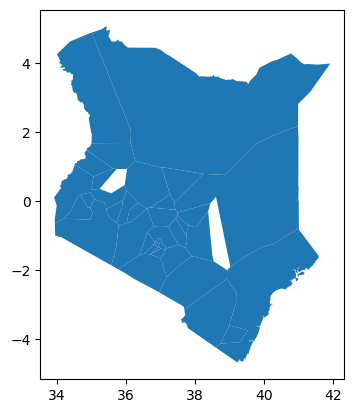

In [10]:
state_gdf.plot()

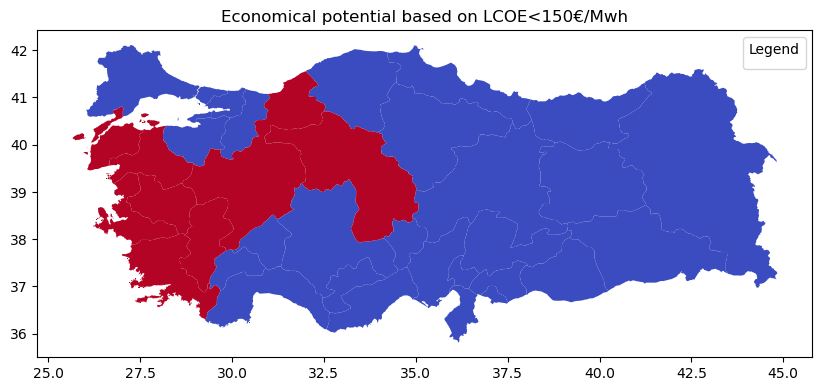

In [6]:
gdf = state_gdf.copy()
# Create a new column 'color' based on the condition you specified
gdf['color'] = 'red'
gdf.loc[gdf['Minimum_LCOE_2030_4326'] >= 150, 'color'] = 'blue'

# Plot the GeoDataFrame with colors
fig, ax = plt.subplots(figsize=(10, 10))

# Plot states with colors based on the 'color' column
gdf.plot(ax=ax, column='color', legend=True, cmap='coolwarm')

# Set the title
plt.title('Economical potential based on LCOE<150€/Mwh')

# Set the legend labels using the 'name' attribute
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Legend')

# Show the plot
plt.show()

____________________________________________

In [7]:
# Rank the values in 'original_column' in ascending order
gdf.loc[gdf['Minimum_LCOE_2030_4326'] < 150, 'rank'] = gdf[gdf['Minimum_LCOE_2030_4326'] < 150]['Minimum_LCOE_2030_4326'].rank(ascending=False)

# Calculate the shares based on the rank (smallest number gets the highest share)
gdf.loc[gdf['Minimum_LCOE_2030_4326'] < 150, 'shares'] = gdf[gdf['Minimum_LCOE_2030_4326'] < 150]['rank'] / gdf[gdf['Minimum_LCOE_2030_4326'] < 150]['rank'].sum()


# Create a new column based on shares
# gdf['potential [MWel]'] = gdf['shares'] * 4500   # The potential of Turkey from Dimitra: Mertoglu, O. et al. (2021): Geothermal Energy Use: Projections and Country Update for Turkey, Proceedings of the World Geothermal Congress 2020+1
gdf['potential [MWel]'] = gdf['shares'] * 7903   # The potential of Turkey from GEOELEC for 2030: https://zenodo.org/records/1283815

# # Drop the intermediate columns if not needed
gdf = gdf.drop(['rank', 'shares'], axis=1)

gdf = gdf.fillna(0)
gdf.to_csv('/nimble/home/edd32710/projects/HyPAT/Turkey/pypsa-earth-sec/data_eddy/geothermal/geothermal_potential.csv')
gdf

,name,x,y,country,geometry,Minimum_LCOE_2030_4326,Minimum_LCOE_2050_4326,color,potential [MWel]
0,TR.11_1_AC,28.010809,37.348943,TR,"MULTIPOLYGON (((27.14181 37.60820, 27.14181 37.60736, 27.14208 37....",125.510490,47.199355,red,878.111111
1,TR.12_1_AC,27.851226,39.864460,TR,"MULTIPOLYGON (((26.52514 39.32125, 26.52514 39.32153, 26.52542 39....",108.075116,44.443867,red,1317.166667
2,TR.13_1_AC,33.411093,41.177268,TR,"MULTIPOLYGON (((32.38958 41.75180, 32.38958 41.75153, 32.38931 41....",220.721916,63.633139,blue,0.000000
3,TR.14_1_AC,41.057949,37.714313,TR,"POLYGON ((43.34621 37.32646, 43.34270 37.32412, 43.33459 37.31871,...",466.317457,85.312849,blue,0.000000
4,TR.15_1_AC,39.471939,40.741039,TR,"MULTIPOLYGON (((38.43736 40.92847, 38.43736 40.92820, 38.43597 40....",244.624017,71.097498,blue,0.000000
5,TR.16_1_AC,30.350671,40.508951,TR,"MULTIPOLYGON (((30.37153 41.17820, 30.37236 41.17820, 30.37236 41....",197.430421,59.238643,blue,0.000000
6,TR.17_1_AC,39.659276,39.097311,TR,"POLYGON ((40.25600 39.97696, 40.25409 39.96883, 40.25179 39.96393,...",230.885512,65.007245,blue,0.000000
7,TR.1_1_AC,35.539192,37.270702,TR,"MULTIPOLYGON (((35.20958 36.64958, 35.20958 36.64931, 35.20930 36....",389.256882,75.053625,blue,0.000000
8,TR.20_1_AC,30.192062,37.378500,TR,"POLYGON ((30.87656 37.35938, 30.87200 37.35568, 30.87008 37.35358,...",212.742202,60.260559,blue,0.000000
9,TR.21_1_AC,29.084379,40.219515,TR,"MULTIPOLYGON (((28.54458 40.56625, 28.54458 40.56597, 28.54653 40....",152.264509,51.371940,blue,0.000000


In [8]:
gdf['potential [MWel]'].sum()

7903.0

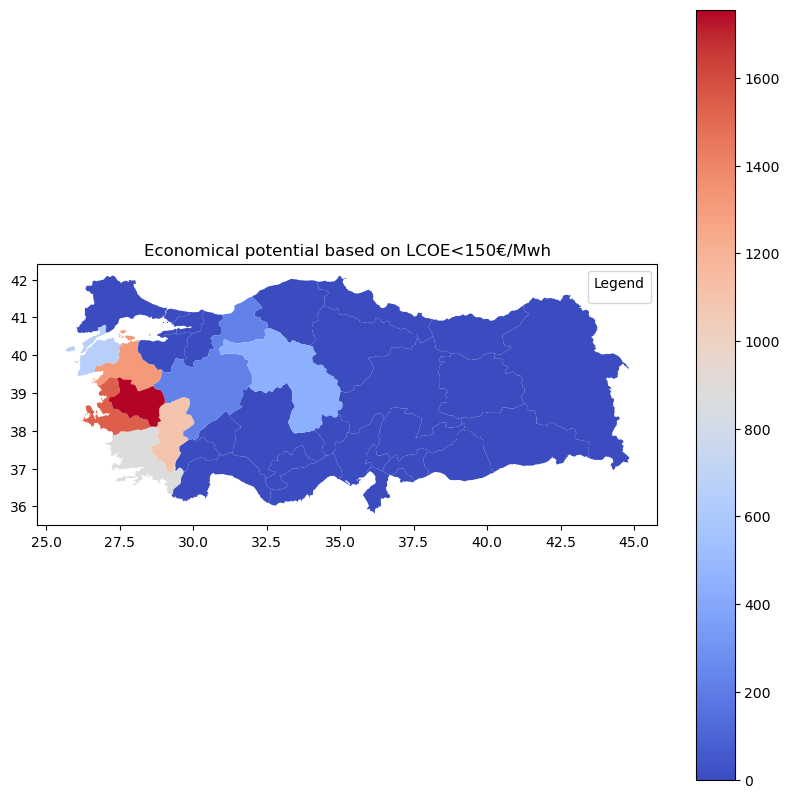

In [9]:
# Plot the GeoDataFrame with colors
fig, ax = plt.subplots(figsize=(10, 10))

# Plot states with colors based on the 'color' column
gdf.plot(ax=ax, column='potential [MWel]', legend=True, cmap='coolwarm')

# Set the title
plt.title('Economical potential based on LCOE<150€/Mwh')

# Set the legend labels using the 'name' attribute
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Legend')

# Show the plot
plt.show()